In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

In [2]:
class BanditEnv:
    """10-armed Gaussian bandit. Each arm: reward ~ N(q*(a), 1)."""
 
    def __init__(self, n_arms=10):
        self.n_arms = n_arms
 
    def reset(self):
        self.q_star = np.random.normal(0, 1, self.n_arms)
        self.optimal_action = np.argmax(self.q_star)
        return 0, {}
 
    def step(self, action):
        reward = np.random.normal(self.q_star[action], 1)
        return 0, reward, False, False, {"is_optimal": int(action == self.optimal_action)}

In [3]:
class EpsilonGreedy:
    """Explore randomly with prob epsilon, otherwise exploit argmax Q."""
 
    def __init__(self, n_arms, epsilon):
        self.n_arms  = n_arms
        self.epsilon = epsilon
 
    def reset(self):
        self.Q = np.zeros(self.n_arms)
        self.N = np.zeros(self.n_arms)
 
    def select_action(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms)
        return np.argmax(self.Q)
 
    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

In [4]:
class UCB:
    """A_t = argmax[ Q(a) + c * sqrt(ln(t) / N(a)) ]"""
 
    def __init__(self, n_arms, c):
        self.n_arms = n_arms
        self.c = c
 
    def reset(self):
        self.Q = np.zeros(self.n_arms)
        self.N = np.zeros(self.n_arms)
        self.t = 0
 
    def select_action(self):
        self.t += 1
        if np.any(self.N == 0):
            return np.argmin(self.N)
        ucb = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)
        return np.argmax(ucb)
 
    def update(self, action, reward):
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

In [5]:
def run_experiment(agent, n_steps=2000, n_runs=1000):
    """Run n_runs independent trials. Returns avg reward and % optimal per step."""
    all_rewards = np.zeros((n_runs, n_steps))
    all_optimal = np.zeros((n_runs, n_steps))
    env = BanditEnv()
    for run in range(n_runs):
        np.random.seed(run)
        env.reset()
        agent.reset()
        for t in range(n_steps):
            action = agent.select_action()
            _, reward, _, _, info = env.step(action)
            agent.update(action, reward)
            all_rewards[run, t] = reward
            all_optimal[run, t] = info["is_optimal"]
    return all_rewards.mean(axis=0), all_optimal.mean(axis=0) * 100

In [6]:
# Run all experiments
eps_values  = [0.01, 0.1, 0.2]
ucb_values  = [0.5, 1.0, 2.0]
steps       = np.arange(1, 2001)
 
eps_results = {e: run_experiment(EpsilonGreedy(10, e)) for e in eps_values}
ucb_results = {c: run_experiment(UCB(10, c))           for c in ucb_values}

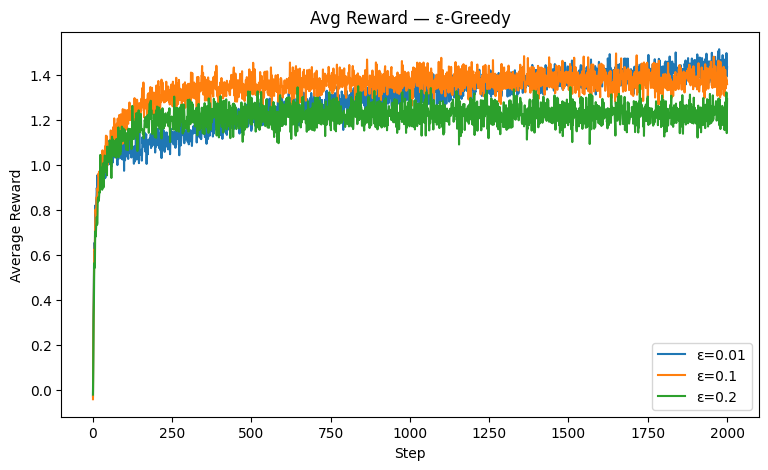

In [18]:
# Chart 1: Average Reward — ε-Greedy
plt.figure(figsize=(9, 5))
for e in eps_values:
    plt.plot(steps, eps_results[e][0], label=f"ε={e}")
plt.title("Avg Reward — ε-Greedy")
plt.xlabel("Step")
plt.ylabel("Average Reward")
plt.legend()
plt.show()

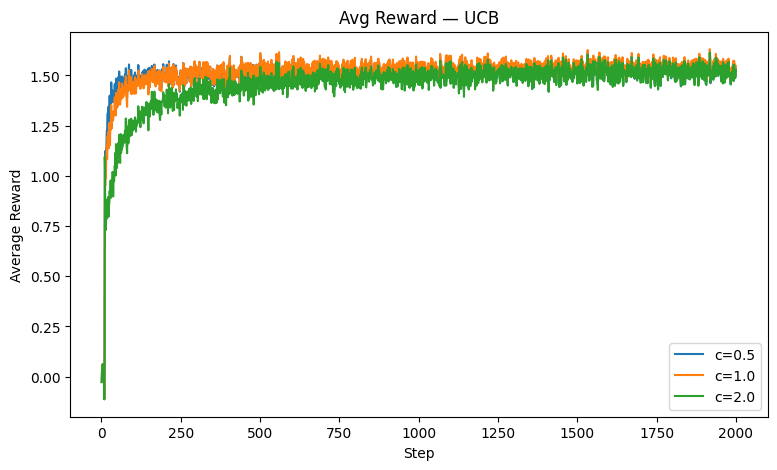

In [19]:
# Chart 2: Average Reward — UCB
plt.figure(figsize=(9, 5))
for c in ucb_values:
    plt.plot(steps, ucb_results[c][0], label=f"c={c}")
plt.title("Avg Reward — UCB")
plt.xlabel("Step")
plt.ylabel("Average Reward")
plt.legend()
plt.show()

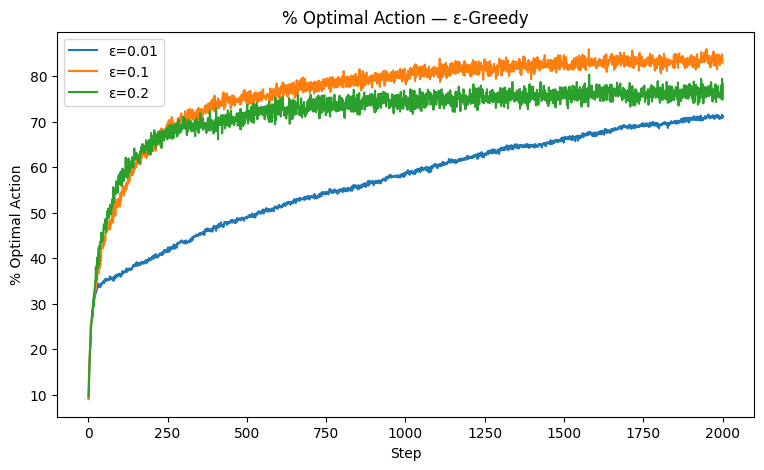

In [20]:
# Chart 3: % Optimal Action — ε-Greedy
plt.figure(figsize=(9, 5))
for e in eps_values:
    plt.plot(steps, eps_results[e][1], label=f"ε={e}")
plt.title("% Optimal Action — ε-Greedy")
plt.xlabel("Step")
plt.ylabel("% Optimal Action")
plt.legend()
plt.show()

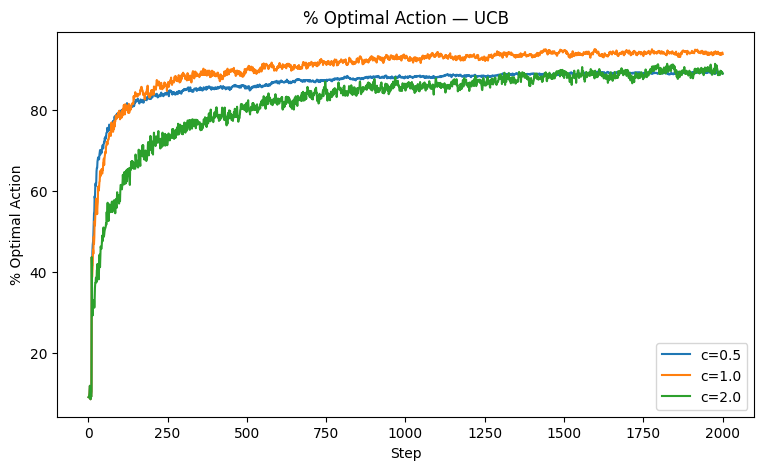

In [28]:
# Chart 4: % Optimal Action — UCB
plt.figure(figsize=(9, 5))
for c in ucb_values:
    plt.plot(steps, ucb_results[c][1], label=f"c={c}")
plt.title("% Optimal Action — UCB")
plt.xlabel("Step")
plt.ylabel("% Optimal Action")
plt.legend()
plt.show()

In [ ]:

# PART 2: Gymnasium Environments + Random Policy
 
def inspect_env(env_id):
    """Create a Gymnasium environment and inspect its MDP components."""
    env = gym.make(env_id)
    obs, _ = env.reset(seed=0)
 
    obs_sp = env.observation_space
    act_sp = env.action_space
 
    # Determine space type and bounds
    def describe_space(space):
        if hasattr(space, "n"):
            return f"Discrete  | n={space.n} | range [0, {space.n-1}]"
        elif hasattr(space, "shape"):
            return (f"Continuous (Box) | shape={space.shape} "
                    f"| low={space.low} | high={space.high}")
        return str(space)
 
    print(f"\n{'='*50}")
    print(f"  Environment : {env_id}")
    print(f"{'='*50}")
    print(f"  S (obs space)  : {describe_space(obs_sp)}")
    print(f"  A (act space)  : {describe_space(act_sp)}")
    print(f"  R (reward)     : scalar float — returned by env.step()")
    print(f"  P (transition) : embedded in env.step() dynamics")
    print(f"  γ (discount)   : agent-defined (e.g. 0.99)")
    print(f"  First obs      : {obs}")
    env.close()

In [23]:
class RandomAgent:
    """Selects actions uniformly at random — ignores observations."""
 
    def __init__(self, n_actions):
        self.n_actions = n_actions
 
    def select_action(self, obs=None):
        return np.random.randint(self.n_actions)

In [24]:
def evaluate_random_policy(env_id, n_episodes=1000, max_steps=200):
    """Run RandomAgent for n_episodes, return episode returns."""
    env = gym.make(env_id)
    agent = RandomAgent(env.action_space.n)
    returns = []
 
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=ep)
        total = 0.0
        for _ in range(max_steps):
            obs, reward, terminated, truncated, _ = env.step(agent.select_action(obs))
            total += reward
            if terminated or truncated:
                break
        returns.append(total)
 
    env.close()
    returns = np.array(returns)
    print(f"\n  {env_id} — Random Policy ({n_episodes} episodes)")
    print(f"    Mean return  : {returns.mean():.3f}")
    print(f"    Success rate : {(returns > 0).mean()*100:.1f}%")
    return returns

In [25]:
# Inspect environments
inspect_env("FrozenLake-v1")
inspect_env("Taxi-v3")


  Environment : FrozenLake-v1
  S (obs space)  : Discrete  | n=16 | range [0, 15]
  A (act space)  : Discrete  | n=4 | range [0, 3]
  R (reward)     : scalar float — returned by env.step()
  P (transition) : embedded in env.step() dynamics
  γ (discount)   : agent-defined (e.g. 0.99)
  First obs      : 0

  Environment : Taxi-v3
  S (obs space)  : Discrete  | n=500 | range [0, 499]
  A (act space)  : Discrete  | n=6 | range [0, 5]
  R (reward)     : scalar float — returned by env.step()
  P (transition) : embedded in env.step() dynamics
  γ (discount)   : agent-defined (e.g. 0.99)
  First obs      : 314


In [26]:
# Evaluate random policy
frozen_returns = evaluate_random_policy("FrozenLake-v1")
taxi_returns   = evaluate_random_policy("Taxi-v3")


  FrozenLake-v1 — Random Policy (1000 episodes)
    Mean return  : 0.010
    Success rate : 1.0%

  Taxi-v3 — Random Policy (1000 episodes)
    Mean return  : -774.463
    Success rate : 0.0%
